In [ ]:
import sys
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
from api_ingestion import read_json, clean_data_api

#get path for dataframes
BASE_DIR = Path().resolve().parent  # if inside analysis folder
DATA_PATH = BASE_DIR / "data" / "valid_data.csv"
df = pd.read_csv(DATA_PATH)
DATA_PATH = BASE_DIR / "data" / "unemployment_data_seed.json"
u_df = read_json(DATA_PATH)
u_df = clean_data_api(u_df)
#print(df.dtypes)
print(u_df.dtypes)

state_fips    string[python]
state         string[python]
date          datetime64[ns]
value                float64
dtype: object


In [11]:
df["indicator"].dropna().unique()

<StringArray>
[                                                      'Received Counseling or Therapy, Last 4 Weeks',
                                       'Took Prescription Medication for Mental Health, Last 4 Weeks',
 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks',
                                      'Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks']
Length: 4, dtype: str

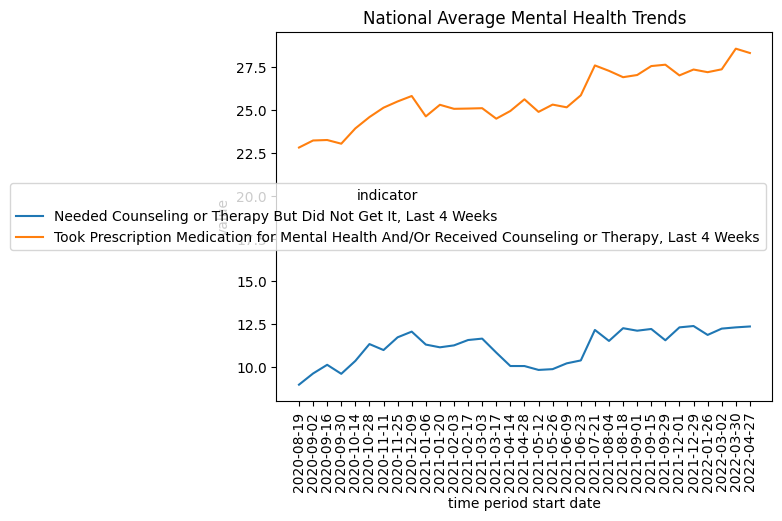

In [18]:
df_useful = df[(df["indicator"] == "Needed Counseling or Therapy But Did Not Get It, Last 4 Weeks") | (df['indicator'] == 'Took Prescription Medication for Mental Health And/Or Received Counseling or Therapy, Last 4 Weeks')]
national = (
    df_useful
    .groupby(["time period start date", "indicator"], as_index=False)["value"]
    .mean()
)

plt.figure()
sns.lineplot(
    data=national,
    x="time period start date",
    y="value",
    hue="indicator"
)
plt.xticks(rotation=90)
plt.title("National Average Mental Health Trends")
plt.show()

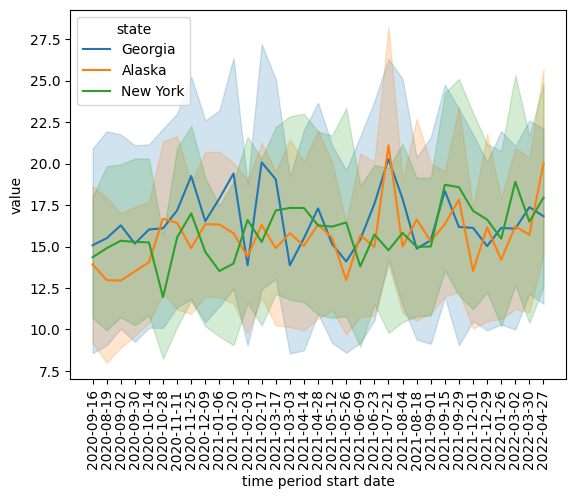

In [19]:
ex = sns.lineplot(data=df,x='time period start date', y='value', hue= 'state', hue_order=['Georgia', 'Alaska','New York'])
ex.tick_params(axis='x', rotation=90)


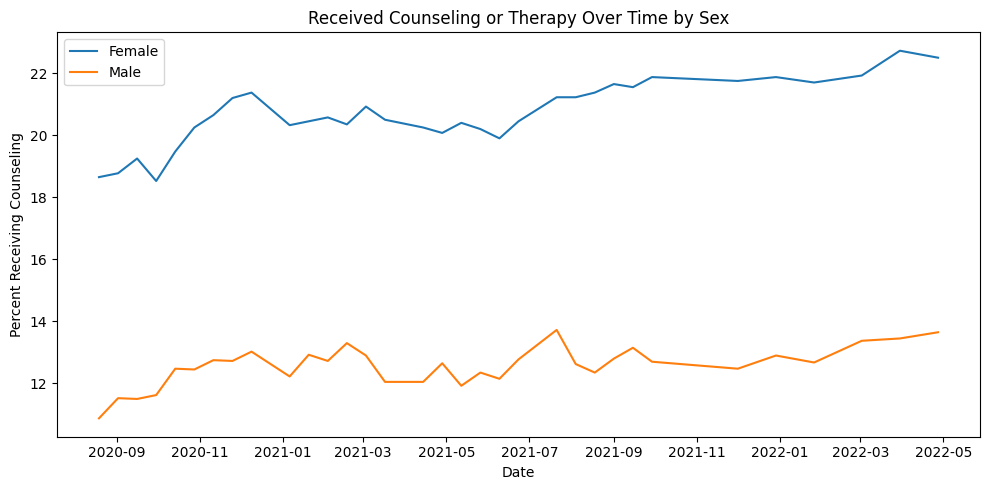

In [ ]:
#did therapy usage increase or decrease over time?(by sex) 

df["time period start date"] = pd.to_datetime(df["time period start date"])

# Filter for sex groups
sex_df = df[df["group"] == "By Sex"]

# Pivot for plotting
pivot = sex_df.pivot_table(index="time period start date",
                      columns="subgroup",
                      values="value",
                      aggfunc="mean")

# Plot
plt.figure(figsize=(10,5))
plt.plot(pivot.index, pivot)
plt.xlabel("Date")
plt.ylabel("Percent Receiving Counseling")
plt.title("Received Counseling or Therapy Over Time by Sex")
plt.legend(pivot.columns)
plt.tight_layout()
plt.show()
